In [1]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:128'
import torch
import torch.nn as nn
import torch.nn.functional as F
import dgl
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from torch.optim import Adam
import scanpy as sc
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [2]:
def js_divergence(p, q, eps=1e-8):
    m = 0.5 * (p + q)
    kl_pm = torch.sum(p * torch.log((p + eps) / (m + eps)), dim=1)
    kl_qm = torch.sum(q * torch.log((q + eps) / (m + eps)), dim=1)
    return 0.5 * (kl_pm + kl_qm).mean()

def zscore_norm(x):
    m = x.mean(dim=0, keepdim=True)
    s = x.std(dim=0, keepdim=True) + 1e-8
    return (x - m) / s

def create_heterogeneous_graph():
    adj_real_pseudo = pd.read_csv('./adj_real_pseudo.csv', index_col=0)
    adj_real_real = pd.read_csv('./adj_real_real.csv', index_col=0)
    adj_realspot_gene = pd.read_csv('./adj_realspot_gene.csv', index_col=0)
    adj_pseuspot_gene = pd.read_csv('./adj_pseuspot_gene.csv', index_col=0)

    ei_rp = torch.tensor(np.array(np.where(adj_real_pseudo.values > 0)), dtype=torch.long)
    ei_rr = torch.tensor(np.array(np.where(adj_real_real.values > 0)), dtype=torch.long)
    ei_rg = torch.tensor(np.array(np.where(adj_realspot_gene.values > 0)), dtype=torch.long)
    ei_pg = torch.tensor(np.array(np.where(adj_pseuspot_gene.values > 0)), dtype=torch.long)

    ew_rp = torch.tensor(adj_real_pseudo.values[adj_real_pseudo.values > 0], dtype=torch.float32, device=device)
    ew_rr = torch.tensor(adj_real_real.values[adj_real_real.values > 0], dtype=torch.float32, device=device)
    ew_rg = torch.tensor(adj_realspot_gene.values[adj_realspot_gene.values > 0], dtype=torch.float32, device=device)
    ew_pg = torch.tensor(adj_pseuspot_gene.values[adj_pseuspot_gene.values > 0], dtype=torch.float32, device=device)

    ei_gr = ei_rg[[1, 0]]
    ei_gp = ei_pg[[1, 0]]
    ew_gr = ew_rg
    ew_gp = ew_pg

    g = dgl.heterograph({
        ('real', 'to_pseudo', 'pseudo'): (ei_rp[0], ei_rp[1]),
        ('real', 'to_real', 'real'): (ei_rr[0], ei_rr[1]),
        ('real', 'expresses_gene', 'gene'): (ei_rg[0], ei_rg[1]),
        ('pseudo', 'expresses_gene', 'gene'): (ei_pg[0], ei_pg[1]),
        ('gene', 'expressed_in_real', 'real'): (ei_gr[0], ei_gr[1]),
        ('gene', 'expressed_in_pseudo', 'pseudo'): (ei_gp[0], ei_gp[1]),
    }).to(device)

    g.nodes['real'].data['feat'] = real_spot_feats
    g.nodes['pseudo'].data['feat'] = pseudo_spot_feats
    g.nodes['gene'].data['feat'] = gene_feats

    g.edges['real', 'to_pseudo', 'pseudo'].data['weight'] = ew_rp
    g.edges['real', 'to_real', 'real'].data['weight'] = ew_rr
    g.edges['real', 'expresses_gene', 'gene'].data['weight'] = ew_rg
    g.edges['pseudo', 'expresses_gene', 'gene'].data['weight'] = ew_pg
    g.edges['gene', 'expressed_in_real', 'real'].data['weight'] = ew_gr
    g.edges['gene', 'expressed_in_pseudo', 'pseudo'].data['weight'] = ew_gp
    return g




class HeteroGAT(nn.Module):
    def __init__(self, in_dim_dict, hidden_dim, num_cell_types, device, num_heads=4, dropout_rate=0.3):
        super().__init__()
        self.device = device
        self.num_heads = num_heads
        self.head_dim = hidden_dim // num_heads

        # W
        self.node_weights1 = nn.ParameterDict({
            'real':   nn.Parameter(torch.randn(in_dim_dict['real'],   hidden_dim, device=device)),
            'pseudo': nn.Parameter(torch.randn(in_dim_dict['pseudo'], hidden_dim, device=device)),
            'gene':   nn.Parameter(torch.randn(in_dim_dict['gene'],   hidden_dim, device=device)),
        })
        self.node_weights2 = nn.ParameterDict({
            'real':   nn.Parameter(torch.randn(hidden_dim, hidden_dim, device=device)),
            'pseudo': nn.Parameter(torch.randn(hidden_dim, hidden_dim, device=device)),
            'gene':   nn.Parameter(torch.randn(hidden_dim, hidden_dim, device=device)),
        })


        self.attn_params1 = nn.ParameterDict({
            'real_from_real':   nn.Parameter(torch.randn(num_heads, in_dim_dict['real']   + self.head_dim, device=device)),
            'real_from_pseudo': nn.Parameter(torch.randn(num_heads, in_dim_dict['real']   + self.head_dim, device=device)),
            'real_from_gene':   nn.Parameter(torch.randn(num_heads, in_dim_dict['real']   + self.head_dim, device=device)),
            'pseudo_from_real': nn.Parameter(torch.randn(num_heads, in_dim_dict['pseudo'] + self.head_dim, device=device)),
            'pseudo_from_gene': nn.Parameter(torch.randn(num_heads, in_dim_dict['pseudo'] + self.head_dim, device=device)),
            'gene_from_real':   nn.Parameter(torch.randn(num_heads, in_dim_dict['gene']   + self.head_dim, device=device)),
            'gene_from_pseudo': nn.Parameter(torch.randn(num_heads, in_dim_dict['gene']   + self.head_dim, device=device)),
        })
        self.attn_params2 = nn.ParameterDict({
            'real_from_real':   nn.Parameter(torch.randn(num_heads, 2*self.head_dim, device=device)),
            'real_from_pseudo': nn.Parameter(torch.randn(num_heads, 2*self.head_dim, device=device)),
            'real_from_gene':   nn.Parameter(torch.randn(num_heads, 2*self.head_dim, device=device)),
            'pseudo_from_real': nn.Parameter(torch.randn(num_heads, 2*self.head_dim, device=device)),
            'pseudo_from_gene': nn.Parameter(torch.randn(num_heads, 2*self.head_dim, device=device)),
            'gene_from_real':   nn.Parameter(torch.randn(num_heads, 2*self.head_dim, device=device)),
            'gene_from_pseudo': nn.Parameter(torch.randn(num_heads, 2*self.head_dim, device=device)),
        })

        self.node_biases = nn.ParameterDict({
            'real':   nn.Parameter(torch.zeros(hidden_dim, device=device)),
            'pseudo': nn.Parameter(torch.zeros(hidden_dim, device=device)),
            'gene':   nn.Parameter(torch.zeros(hidden_dim, device=device)),
        })

        self.dropout = nn.Dropout(dropout_rate)
        self.pseudo_out = nn.Linear(hidden_dim, num_cell_types)

        # init
        for n in self.node_weights1:
            nn.init.xavier_uniform_(self.node_weights1[n])
            nn.init.xavier_uniform_(self.node_weights2[n])
        for k in self.attn_params1:
            nn.init.xavier_uniform_(self.attn_params1[k])
        for k in self.attn_params2:
            nn.init.xavier_uniform_(self.attn_params2[k])
        nn.init.xavier_uniform_(self.pseudo_out.weight)
        self.pseudo_out.bias.data.zero_()

    def edge_type(self, src_type, dst_type):
        if src_type == 'real' and dst_type == 'real':   return 'to_real'
        if src_type == 'real' and dst_type == 'pseudo': return 'to_pseudo'
        if src_type == 'real' and dst_type == 'gene':   return 'expresses_gene'
        if src_type == 'pseudo' and dst_type == 'gene': return 'expresses_gene'
        if src_type == 'gene' and dst_type == 'real':   return 'expressed_in_real'
        if src_type == 'gene' and dst_type == 'pseudo': return 'expressed_in_pseudo'
        return None


    def attn_first_layer(self, graph, src_type, dst_type, h_src, h_dst, W_src, attn_param):
        Wh_src = (h_src @ W_src).view(-1, self.num_heads, self.head_dim)
        out, etype = [], self.edge_type(src_type, dst_type)
        for i in range(h_dst.shape[0]):
            if etype is None:
                out.append(torch.zeros(self.num_heads*self.head_dim, device=h_dst.device)); continue
            nbr = graph.predecessors(i, etype=(src_type, etype, dst_type))
            if len(nbr) == 0:
                out.append(torch.zeros(self.num_heads*self.head_dim, device=h_dst.device)); continue
            
            v = torch.full((len(nbr),), i, dtype=nbr.dtype, device=nbr.device)
            eids = graph.edge_ids(nbr, v, etype=(src_type, etype, dst_type))
            w = graph.edges[(src_type, etype, dst_type)].data['weight'][eids].to(Wh_src.device)
            multi = []
            for head in range(self.num_heads):
                h_dst_i = h_dst[i].unsqueeze(0).expand(len(nbr), -1)
                Wh_src_n = Wh_src[nbr, head, :]
                attn_in = torch.cat([h_dst_i, Wh_src_n], dim=1)               # [K, in_dim_dst + D]
                e_ij = F.leaky_relu(attn_in @ attn_param[head].unsqueeze(-1)).squeeze(-1)
                
                e_ij = e_ij + 0.1 * torch.log(w + 1e-8)
                alpha = torch.softmax(e_ij, dim=0)
                agg = (alpha.unsqueeze(-1) * Wh_src_n).sum(dim=0)             # [D]
                multi.append(agg)
            out.append(torch.cat(multi, dim=0))                                # [H*D]
        return torch.stack(out, dim=0)                                         # [N_dst,H*D]

   
    def attn_second_layer(self, graph, src_type, dst_type, h_src, h_dst, W_src, W_dst, attn_param):
        Wh_src = (h_src @ W_src).view(-1, self.num_heads, self.head_dim)
        Wh_dst = (h_dst @ W_dst).view(-1, self.num_heads, self.head_dim)
        out, etype = [], self.edge_type(src_type, dst_type)
        for i in range(h_dst.shape[0]):
            if etype is None:
                out.append(torch.zeros(self.num_heads*self.head_dim, device=h_dst.device)); continue
            nbr = graph.predecessors(i, etype=(src_type, etype, dst_type))
            if len(nbr) == 0:
                out.append(torch.zeros(self.num_heads*self.head_dim, device=h_dst.device)); continue
           
            v = torch.full((len(nbr),), i, dtype=nbr.dtype, device=nbr.device)
            eids = graph.edge_ids(nbr, v, etype=(src_type, etype, dst_type))
            w = graph.edges[(src_type, etype, dst_type)].data['weight'][eids].to(Wh_src.device)
            multi = []
            for head in range(self.num_heads):
                Wh_dst_i = Wh_dst[i, head, :].unsqueeze(0).expand(len(nbr), -1)
                Wh_src_n = Wh_src[nbr, head, :]
                attn_in = torch.cat([Wh_dst_i, Wh_src_n], dim=1)               # [K, 2D]
                e_ij = F.leaky_relu(attn_in @ attn_param[head].unsqueeze(-1)).squeeze(-1)
                e_ij = e_ij + 0.1 * torch.log(w + 1e-8)
                alpha = torch.softmax(e_ij, dim=0)
                agg = (alpha.unsqueeze(-1) * Wh_src_n).sum(dim=0)
                multi.append(agg)
            out.append(torch.cat(multi, dim=0))
        return torch.stack(out, dim=0)

    def post(self, h_old, h_new):
        h = h_new + h_old
        h = F.layer_norm(h, h.shape[-1:])
        return F.gelu(h)

    def custom_update_layer1(self, graph, h_real, h_pseudo, h_gene):
        # real <- {pseudo, real, gene}
        r_from_p = self.attn_first_layer(graph, 'pseudo','real', h_pseudo, h_real, self.node_weights1['pseudo'], self.attn_params1['real_from_pseudo'])
        r_from_r = self.attn_first_layer(graph, 'real',  'real', h_real,   h_real, self.node_weights1['real'],   self.attn_params1['real_from_real'])
        r_from_g = self.attn_first_layer(graph, 'gene',  'real', h_gene,   h_real, self.node_weights1['gene'],   self.attn_params1['real_from_gene'])
        r_self = h_real @ self.node_weights1['real']
        h_real_new = self.dropout(F.relu(r_self + r_from_p + r_from_r + r_from_g + self.node_biases['real']))
        
    
        # pseudo <- {real, gene}
        p_from_r = self.attn_first_layer(graph, 'real', 'pseudo', h_real,   h_pseudo, self.node_weights1['real'],  self.attn_params1['pseudo_from_real'])
        p_from_g = self.attn_first_layer(graph, 'gene', 'pseudo', h_gene,   h_pseudo, self.node_weights1['gene'],  self.attn_params1['pseudo_from_gene'])
        p_self = h_pseudo @ self.node_weights1['pseudo']
        h_pseudo_new = self.dropout(F.relu(p_self + p_from_r + p_from_g + self.node_biases['pseudo']))
       
    
        # gene <- {pseudo, real}
        g_from_p = self.attn_first_layer(graph, 'pseudo','gene', h_pseudo, h_gene, self.node_weights1['pseudo'], self.attn_params1['gene_from_pseudo'])
        g_from_r = self.attn_first_layer(graph, 'real',  'gene', h_real,   h_gene, self.node_weights1['real'],   self.attn_params1['gene_from_real'])
        g_self = h_gene @ self.node_weights1['gene']
        h_gene_new = self.dropout(F.relu(g_self + g_from_p + g_from_r + self.node_biases['gene']))
      
        
        return h_real_new, h_pseudo_new, h_gene_new
    
    def custom_update_layer2(self, graph, h_real, h_pseudo, h_gene):
        # real <- {pseudo, real, gene}
        r_from_p = self.attn_second_layer(graph, 'pseudo','real', h_pseudo, h_real, self.node_weights2['pseudo'], self.node_weights2['real'], self.attn_params2['real_from_pseudo'])
        r_from_r = self.attn_second_layer(graph, 'real',  'real', h_real,   h_real, self.node_weights2['real'],   self.node_weights2['real'], self.attn_params2['real_from_real'])
        r_from_g = self.attn_second_layer(graph, 'gene',  'real', h_gene,   h_real, self.node_weights2['gene'],   self.node_weights2['real'], self.attn_params2['real_from_gene'])
        r_self = h_real @ self.node_weights2['real']
        h_real_new = self.dropout(F.relu(r_self + r_from_p + r_from_r + r_from_g + self.node_biases['real']))
        
        h_real_new = self.post(h_real, h_real_new)
    
        # pseudo <- {real, gene}
        p_from_r = self.attn_second_layer(graph, 'real','pseudo', h_real,   h_pseudo, self.node_weights2['real'],  self.node_weights2['pseudo'], self.attn_params2['pseudo_from_real'])
        p_from_g = self.attn_second_layer(graph, 'gene','pseudo', h_gene,   h_pseudo, self.node_weights2['gene'],  self.node_weights2['pseudo'], self.attn_params2['pseudo_from_gene'])
        p_self = h_pseudo @ self.node_weights2['pseudo']
        h_pseudo_new = self.dropout(F.relu(p_self + p_from_r + p_from_g + self.node_biases['pseudo']))
        
        h_pseudo_new = self.post(h_pseudo, h_pseudo_new)
    
        # gene <- {pseudo, real}
        g_from_p = self.attn_second_layer(graph, 'pseudo','gene', h_pseudo, h_gene, self.node_weights2['pseudo'], self.node_weights2['gene'], self.attn_params2['gene_from_pseudo'])
        g_from_r = self.attn_second_layer(graph, 'real',  'gene', h_real,   h_gene, self.node_weights2['real'],   self.node_weights2['gene'], self.attn_params2['gene_from_real'])
        g_self = h_gene @ self.node_weights2['gene']
        h_gene_new = self.dropout(F.relu(g_self + g_from_p + g_from_r + self.node_biases['gene']))
        
        h_gene_new = self.post(h_gene, h_gene_new)
        
        return h_real_new, h_pseudo_new, h_gene_new

    
    def forward(self, graph):
        h_real = graph.nodes['real'].data['feat']
        h_pseudo = graph.nodes['pseudo'].data['feat']
        h_gene = graph.nodes['gene'].data['feat']
        h_real, h_pseudo, h_gene = self.custom_update_layer1(graph, h_real, h_pseudo, h_gene)
        h_real, h_pseudo, h_gene = self.custom_update_layer2(graph, h_real, h_pseudo, h_gene)
        return self.pseudo_out(h_pseudo)
    
from torch.cuda.amp import autocast, GradScaler
def train(model, graph, epochs=300, lr=1e-3, T=1.2, entropy_lambda=3e-3):
    optim = Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scaler = GradScaler()
    losses = []
    for ep in range(epochs):
        model.train()
        optim.zero_grad(set_to_none=True)
        with autocast(dtype=torch.float16):
            logits = model(graph)
            p = torch.softmax(logits / T, dim=1)
            jsd = js_divergence(p.float(), pseudo_labels)
            mse = F.mse_loss(p.float(), pseudo_labels)
            entropy_reg = (p * torch.log(p + 1e-8)).sum(dim=1).mean()
            w_mse = 1.0 if ep < 100 else (0.5 if ep < 200 else 0.2)
            loss = jsd + w_mse * mse + entropy_lambda * entropy_reg
        scaler.scale(loss).backward()
        scaler.step(optim)
        scaler.update()
        if (ep+1) % 10 == 0 or ep == 0:
            print(f"Epoch {ep+1}/{epochs} | Loss {loss.item():.6f} | JSD {jsd.item():.6f} | MSE {mse.item():.6f}")
        losses.append(loss.item())
    return losses

In [3]:

real_spot_data = pd.read_csv('./real_spot_shared_genes.csv')
pseudo_spot_data = pd.read_csv('./pseudo_spot_shared_genes.csv')

real_spot_data = real_spot_data.drop(columns=["Unnamed: 0"]).values
pseudo_spot_data = pseudo_spot_data.drop(columns=["Unnamed: 0"]).values

import anndata
adata_real = anndata.AnnData(real_spot_data)
adata_pseudo = anndata.AnnData(pseudo_spot_data)


sc.pp.log1p(adata_real)
sc.pp.log1p(adata_pseudo)

real_spot_feats = torch.tensor(adata_real.X, dtype=torch.float32).to(device)
pseudo_spot_feats = torch.tensor(adata_pseudo.X, dtype=torch.float32).to(device)
num_genes = real_spot_feats.shape[1]

real_spot_feats = zscore_norm(real_spot_feats)
pseudo_spot_feats = zscore_norm(pseudo_spot_feats)


all_spot_feats = torch.cat([real_spot_feats, pseudo_spot_feats], dim=0)  # [num_spot, num_genes]
gene_by_spot = all_spot_feats.cpu().numpy().T  # [num_genes, num_spot]
pca_dim = 16
pca = PCA(n_components=pca_dim)
gene_feats_pca = pca.fit_transform(gene_by_spot)  # [num_genes, 8]
gene_feats = torch.tensor(gene_feats_pca, dtype=torch.float32, device=all_spot_feats.device)

mean = gene_feats.mean(dim=0, keepdim=True)
std = gene_feats.std(dim=0, keepdim=True) + 1e-8
gene_feats = (gene_feats - mean) / std

# real_spot_feats = torch.tensor(real_spot_data.drop(columns=["Unnamed: 0"]).values, dtype=torch.float32).to(device)
# pseudo_spot_feats = torch.tensor(pseudo_spot_data.drop(columns=["Unnamed: 0"]).values, dtype=torch.float32).to(device)


# gene_feats = torch.randn(num_genes, 1150) 




num_real_spots = real_spot_feats.size(0)
num_pseudo_spots = pseudo_spot_feats.size(0)
real_spot_feats,num_genes

C:\Users\lenovo\AppData\Local\Temp\ipykernel_23448\3781829457.py:9: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata_real = anndata.AnnData(real_spot_data)
C:\Users\lenovo\AppData\Local\Temp\ipykernel_23448\3781829457.py:10: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata_pseudo = anndata.AnnData(pseudo_spot_data)


(tensor([[-1.0499, -0.3499,  0.3456,  ..., -0.3185, -0.3742, -0.4080],
         [ 0.6726,  1.5138,  2.0819,  ..., -0.3185, -0.3742, -0.4080],
         [ 0.4648,  1.3539,  0.7995,  ..., -0.3185, -0.3742, -0.4080],
         ...,
         [-1.0985,  0.0678, -0.3336,  ..., -0.3185, -0.3742, -0.4080],
         [-3.6328, -0.8116, -1.3642,  ..., -0.3185, -0.3742,  1.7070],
         [-0.3490,  1.3152,  1.3843,  ..., -0.3185, -0.3742, -0.4080]],
        device='cuda:0'),
 1150)

In [4]:
graph = create_heterogeneous_graph()
print(f"Graph nodes: real={graph.num_nodes('real')}, pseudo={graph.num_nodes('pseudo')}, gene={graph.num_nodes('gene')}")

Graph nodes: real=260, pseudo=500, gene=1150


In [5]:

pseudo_labels = pd.read_csv('./pseudo_spot_label_fractions.csv').values
num_cell_types = pseudo_labels.shape[1]
pseudo_labels = torch.tensor(pseudo_labels, dtype=torch.float32, device=device)
pseudo_labels = pseudo_labels + 1e-8
pseudo_labels = pseudo_labels / pseudo_labels.sum(dim=1, keepdim=True)
# label smoothing
eps = 0.1
pseudo_labels = pseudo_labels * (1 - eps) + eps / num_cell_types

In [6]:

in_dim_dict = {'real': real_spot_feats.shape[1], 'pseudo': pseudo_spot_feats.shape[1], 'gene': gene_feats.shape[1]}
model = HeteroGAT(in_dim_dict=in_dim_dict, hidden_dim=128, num_cell_types=num_cell_types, device=device, num_heads=2, dropout_rate=0.3).to(device)
graph.nodes['real'].data['feat'][0]

tensor([-1.0499, -0.3499,  0.3456,  ..., -0.3185, -0.3742, -0.4080],
       device='cuda:0')

Epoch 1/500 | Loss 0.304980 | JSD 0.213348 | MSE 0.095711
Epoch 10/500 | Loss 0.040030 | JSD 0.033441 | MSE 0.008472
Epoch 20/500 | Loss 0.032101 | JSD 0.027404 | MSE 0.006739
Epoch 30/500 | Loss 0.024014 | JSD 0.021071 | MSE 0.005449
Epoch 40/500 | Loss 0.022154 | JSD 0.019736 | MSE 0.004852
Epoch 50/500 | Loss 0.017707 | JSD 0.016409 | MSE 0.003663
Epoch 60/500 | Loss 0.014613 | JSD 0.014066 | MSE 0.003064
Epoch 70/500 | Loss 0.013380 | JSD 0.012894 | MSE 0.002928
Epoch 80/500 | Loss 0.013159 | JSD 0.012659 | MSE 0.002954
Epoch 90/500 | Loss 0.010838 | JSD 0.010965 | MSE 0.002384
Epoch 100/500 | Loss 0.010143 | JSD 0.010296 | MSE 0.002319
Epoch 110/500 | Loss 0.008697 | JSD 0.010088 | MSE 0.002367
Epoch 120/500 | Loss 0.006996 | JSD 0.008508 | MSE 0.001908
Epoch 130/500 | Loss 0.006726 | JSD 0.008325 | MSE 0.001875
Epoch 140/500 | Loss 0.005837 | JSD 0.007555 | MSE 0.001645
Epoch 150/500 | Loss 0.006123 | JSD 0.007799 | MSE 0.001738
Epoch 160/500 | Loss 0.005192 | JSD 0.006971 | MSE 

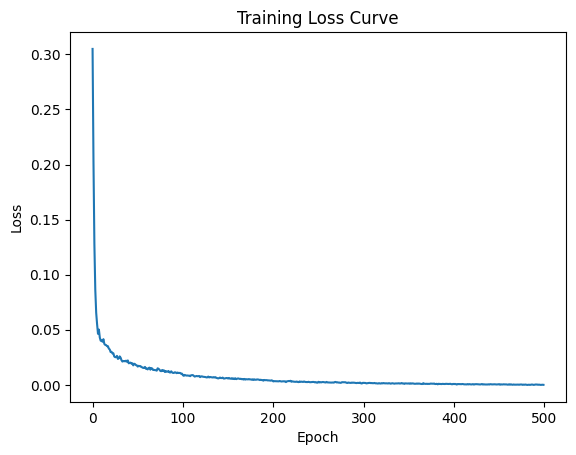

In [7]:
losses = train(model, graph, epochs=500, lr=5e-4)


plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title('Training Loss Curve')
plt.show()

In [8]:


real_spot_df = pd.read_csv('./real_spot_shared_genes.csv', index_col=0)
real_index = real_spot_df.index
label_columns = pd.read_csv('./pseudo_spot_label_fractions.csv', nrows=0).columns.tolist()

model.eval()
with torch.no_grad():
    h_real = graph.nodes['real'].data['feat']
    h_pseudo = graph.nodes['pseudo'].data['feat']
    h_gene = graph.nodes['gene'].data['feat']

    h_real, h_pseudo, h_gene = model.custom_update_layer1(graph, h_real, h_pseudo, h_gene)
    h_real, h_pseudo, h_gene = model.custom_update_layer2(graph, h_real, h_pseudo, h_gene)

    
    preds, bs = [], 64
    for i in range(0, h_real.size(0), bs):
        logits = model.pseudo_out(h_real[i:i+bs])
        preds.append(torch.softmax(logits / 1.2, dim=1).cpu())
    real_pred = torch.cat(preds, dim=0)

    
    assert len(real_index) == real_pred.size(0) == graph.num_nodes('real')
    df_real_pred = pd.DataFrame(real_pred.numpy(), index=real_index, columns=label_columns)
    df_real_pred.to_csv('base_v1.csv', float_format='%.6f')